<a href="https://colab.research.google.com/github/ShotaSasaki-HU/Prog2kakushin/blob/main/work2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

シミュレーション結果を保存します。
ファイル名（拡張子を除く）：temp


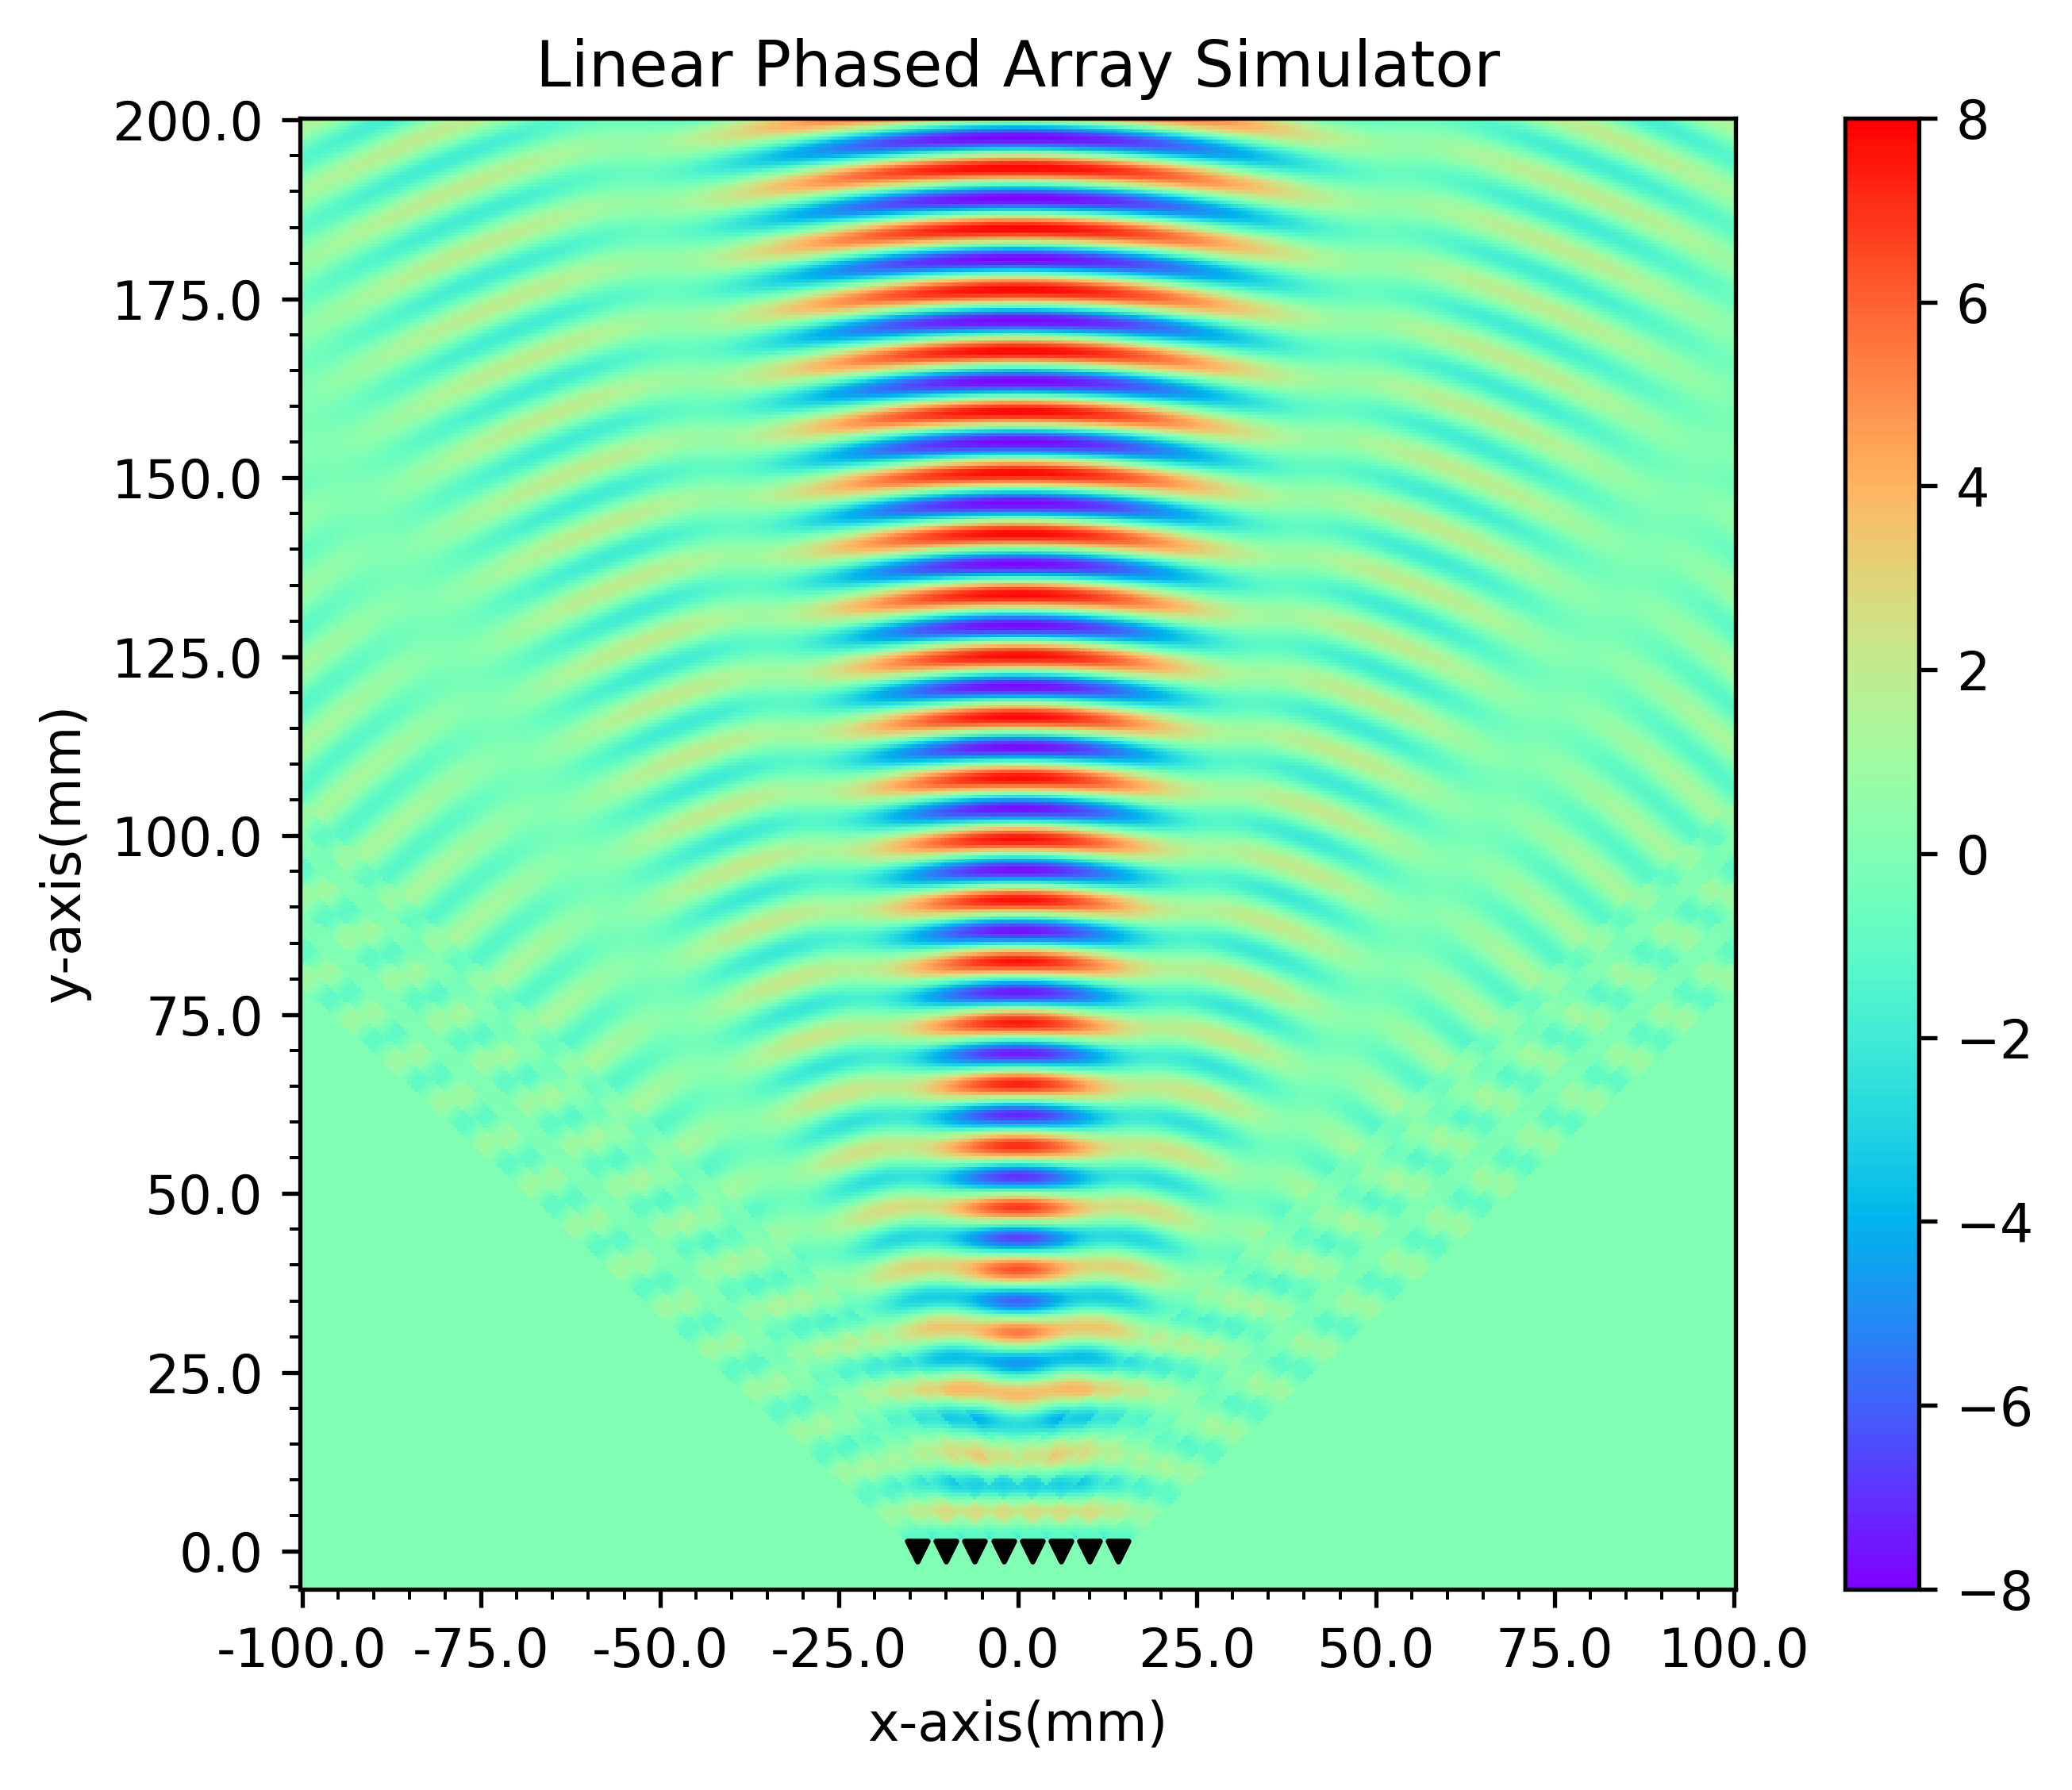

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from PIL import Image

def linear_phased_array(A=1, f=40000, v=340.29*1000, t=0, range_x_R=50, range_x_L=-50, range_y_T=100, range_y_B=-10, calc_width=1, tr_num=8, tr_directivity=np.deg2rad(95), tr_clearance=4, tr_marker=True, tr_marker_s = 15, beam_direction=np.deg2rad(90), use_focusing_mode=False, focusing_point=(0,40), use_grid2image=False, use_gif='disabled', name=0, dura=20):
  # 送信素子をx軸上に原点が中心となる様に配置する。それらの座標を計算してtr_x_coordに格納する。
  tr_x_coord = [] # 送信素子のx座標（y座標は0で固定）
  if (tr_num % 2) == 1: # 送信素子数が奇数個のとき
    for n in range(0, tr_num):
      tr_x_coord.append(-((tr_num // 2) * tr_clearance) + (n * tr_clearance))
  else: # 送信素子数が偶数個のとき
    for n in range(0, tr_num):
      tr_x_coord.append(-(((tr_num // 2) * tr_clearance) - (tr_clearance / 2)) + (n * tr_clearance))

  # 指定されたレンジを満たす（必要最小限は超える）Numpy２次元配列を0埋めで作成する。
  sim_result = np.zeros((int(np.ceil((range_y_T - range_y_B) / calc_width) + 1), int(np.ceil((range_x_R - range_x_L) / calc_width) + 1)))

  # 計算座標の生成
  x_coords = range_x_L + np.arange(sim_result.shape[1]) * calc_width
  y_coords = range_y_T - np.arange(sim_result.shape[0]) * calc_width
  # x座標の行列, y座標の行列
  x, y = np.meshgrid(x_coords, y_coords) # (H, W)

  # 送信素子座標（y座標は0で固定）
  tr_x_coord = np.array(tr_x_coord) # (N, )
  tr_y_coord = np.zeros_like(tr_x_coord) # (N, )

  # 送信素子座標の次元を拡張
  tr_x = tr_x_coord[:, None, None] # (N, 1, 1)
  tr_y = tr_y_coord[:, None, None] # (N, 1, 1)

  # 送信素子から計算座標への相対ベクトル
  relv_x = x[None, :, :] - tr_x # (N, H, W) = (1, H, W) - (N, 1, 1)
  relv_y = y[None, :, :] - tr_y # (N, H, W) = (1, H, W) - (N, 1, 1)

  # 送信素子と計算座標の距離
  dist = np.hypot(relv_x, relv_y) # (N, H, W)

  # 送信素子に対する計算座標の角度
  # arctan2(dx, dy)（y軸の正方向が基準）。
  angles = np.arctan2(relv_x, relv_y) # (N, H, W)

  # 指向性マスク
  directivity_mask = np.abs(angles) <= (tr_directivity / 2) # (N, H, W)

  # 位相差
  if not use_focusing_mode: # ビームフォーミングモード時の位相差計算
      phase_diff = np.arange(tr_num) * tr_clearance * np.sin(beam_direction - (np.pi / 2)) # (N, )
  else: # 集束モード時の位相差計算
      tr_positions = np.stack([tr_x_coord, tr_y_coord], axis=1) # (N, 2) = (N, )と(N, )を第1軸で結合
      # d_ini (float): 左端の送信素子と集束点の距離（スカラー）
      d_ini = np.linalg.norm(np.array(focusing_point) - tr_positions[0]) # ()
      phase_diff = np.linalg.norm(np.array(focusing_point) - tr_positions, axis=1) - d_ini # (N, ) = (N, ) - ()

  phase_diff = phase_diff[:, None, None] # (N, 1, 1)

  # 波の計算
  wave = A * np.sin(2 * np.pi * f * (t - (dist / v) + (phase_diff / v))) # (N, H, W)

  # マスクの適用
  wave *= directivity_mask # (N, H, W)

  # 波の重ね合わせ
  sim_result = np.sum(wave, axis=0) # (H, W)

  if not use_grid2image:
    # ここからヒートマップの表示設定
    fig, ax = plt.subplots(dpi=480)
    im = ax.imshow(sim_result, cmap='rainbow', aspect='equal', vmin=-A*tr_num, vmax=A*tr_num)
    plt.colorbar(im)
    # x軸目盛りの設定
    ax.set_xticks(np.arange(0, sim_result.shape[1], 1))
    ax.set_xticklabels(np.linspace(range_x_L, range_x_L+(calc_width*(sim_result.shape[1]-1)), sim_result.shape[1]))
    ax.xaxis.set_major_locator(ticker.AutoLocator()) # 過剰に指定された目盛りを自動調整
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator()) # 副目盛りで主目盛りを自動補完
    # y軸目盛りの設定
    ax.set_yticks(np.arange(sim_result.shape[0]-1, 0-1, -1))
    ax.set_yticklabels(np.linspace(range_y_T-(calc_width*(sim_result.shape[0]-1)), range_y_T, sim_result.shape[0]))
    ax.yaxis.set_major_locator(ticker.AutoLocator()) # 過剰に指定された目盛りを自動調整
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator()) # 副目盛りで主目盛りを自動補完
    # タイトル・軸ラベルの設定
    ax.set_title('Linear Phased Array Simulator')
    ax.set_xlabel('x-axis(mm)')
    ax.set_ylabel('y-axis(mm)')
    # 送信素子の位置をプロット（tr_marker=Trueの場合）
    if tr_marker:
      tr_x_coord_idx = []
      for i in range(0, len(tr_x_coord)):
        tr_x_coord_idx.append(np.abs(np.linspace(range_x_L, range_x_L+(calc_width*(sim_result.shape[1]-1)), sim_result.shape[1]) - tr_x_coord[i]).argmin())
      tr_y_coord_idx = [np.abs(np.linspace(range_y_T, range_y_T-(calc_width*(sim_result.shape[0]-1)), sim_result.shape[0]) - 0).argmin()] * len(tr_x_coord)
      ax.scatter(tr_x_coord_idx, tr_y_coord_idx, c='k', marker='v', s=tr_marker_s)
    # 無駄な余白を消す。これは、全てのaxが追加された後に実行されなければならない。
    fig.tight_layout()
    if use_gif == 'disabled':
      name = input("シミュレーション結果を保存します。\nファイル名（拡張子を除く）：")
      plt.savefig(name + '.png', dpi=480)
      return
    else: # アニメーション用番号付き画像保存
      plt.savefig(str(name) + '.png', dpi=480)
      plt.close() # 保存するたびに出力欄に画像が表示されるのを防止
  else:
    fig, ax = plt.subplots(figsize=sim_result.shape[::-1], dpi=1, tight_layout=True)
    ax.imshow(sim_result, cmap='rainbow', aspect='equal', vmin=-A*tr_num, vmax=A*tr_num)
    ax.axis('off')
    if use_gif == 'disabled':
      name = input("シミュレーション結果を保存します。\nファイル名（拡張子を除く）：")
      plt.savefig(name + '.png', dpi=1)
      return
    else: # アニメーション用番号付き画像保存
      plt.savefig(str(name) + '.png', dpi=1)
      plt.close() # 保存するたびに出力欄に画像が表示されるのを防止

  divide = 10
  if name == (divide - 1):
    pictures=[] # 画像を入れる箱を準備
    # 画像を箱に入れていく
    for i in range(0, divide):
      path = str(i) + '.png'
      img = Image.open(path)
      pictures.append(img)
    # gifアニメを出力する
    name_gif = input("シミュレーション結果をGIFアニメーションで保存します。\nファイル名（拡張子を除く）：")
    pictures[0].save(name_gif + '.gif',save_all=True, append_images=pictures[1:], optimize=True, duration=dura, loop=0) # duration = 20ms が下界
    return

  if use_gif == 'periodic_loop':
    linear_phased_array(A, f, v, t+((1/f)/divide), range_x_R, range_x_L, range_y_T, range_y_B, calc_width, tr_num, tr_directivity, tr_clearance, tr_marker, tr_marker_s, beam_direction, use_focusing_mode, focusing_point, use_grid2image, use_gif, name+1, dura)
  elif (use_gif == 'steering') and (not use_focusing_mode):
    linear_phased_array(A, f, v, t, range_x_R, range_x_L, range_y_T, range_y_B, calc_width, tr_num, tr_directivity, tr_clearance, tr_marker, tr_marker_s, beam_direction-((np.pi/2)/divide), use_focusing_mode, focusing_point, use_grid2image, use_gif, name+1, dura)
  elif (use_gif == 'steering') and use_focusing_mode:
    print("［エラー］use_gif='steering'は、ビームフォーミングモード専用のGIF生成機能です。集束モード（use_focusing_mode=True）では、使用できません。")
  else:
    print("［エラー］引数use_gifに、'" + str(use_gif) + "'という設定は存在しません。'disabled'か'periodic_loop'か'steering'のどれかを指定してください。")

  return

######################### 以下にコードを書きましょう。##########################

linear_phased_array(A = 1, # 送信波の振幅(mm)
                    f = 40000, # 送信波の周波数(Hz)
                    v = 340.29*1000, # 送信波の速さ(mm/s)
                    t = 0, # 時間(s)

                    range_x_R = 100, # x軸方向レンジ右(mm)
                    range_x_L = -100, # x軸方向レンジ左(mm)
                    range_y_T = 200, # y軸方向レンジ上(mm)
                    range_y_B = -5, # y軸方向レンジ下(mm)
                    calc_width = 0.5, # 計算幅(mm) # 波長の８分の１くらいを推奨

                    tr_num = 8, # 送信素子数（個）
                    tr_directivity = np.deg2rad(95), # 送信素子指向性(rad)
                    tr_clearance = 4, # 送信素子間隔(mm)
                    tr_marker = True, # 送信素子マーカー描写の有無
                    tr_marker_s = 15, # 送信素子マーカーの大きさ

                    # ビームフォーミングモード（デフォルト）
                    beam_direction = np.deg2rad(90), # 合成波の指向方向(rad)

                    # 集束モード（ビームフォーカシングモード）
                    use_focusing_mode = False, # Trueで集束モードを有効化
                    focusing_point = (0,60), # 集束点の座標

                    # ２次元配列の要素数に合わせた画像を保存する機能
                    use_grid2image = False, # Trueで機能を有効化

                    # GIFアニメーションを生成する機能
                    use_gif = 'disabled', # 'periodic_loop'か'steering'のどちらかで有効化
                    name = 0, # 結果を保存する際に内部的に使用されるファイル名の変数
                    dura = 20 # GIFアニメーションの画像１枚あたりの持続時間(ms)
                    )
